# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings
import pingouin as pg

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/test.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 150
Variables catégorielles: 4


Analyse des valeurs manquantes
                     nb_missing    pct
xa                          630  35.98
xg_buildup                  630  35.98
xg_buildup_nor              630  35.98
xa_nor                      630  35.98
Subs_Mn/Sub_nor             242  13.82
Subs_Mn/Sub                 242  13.82
Team Success_On-Off          18   1.03

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


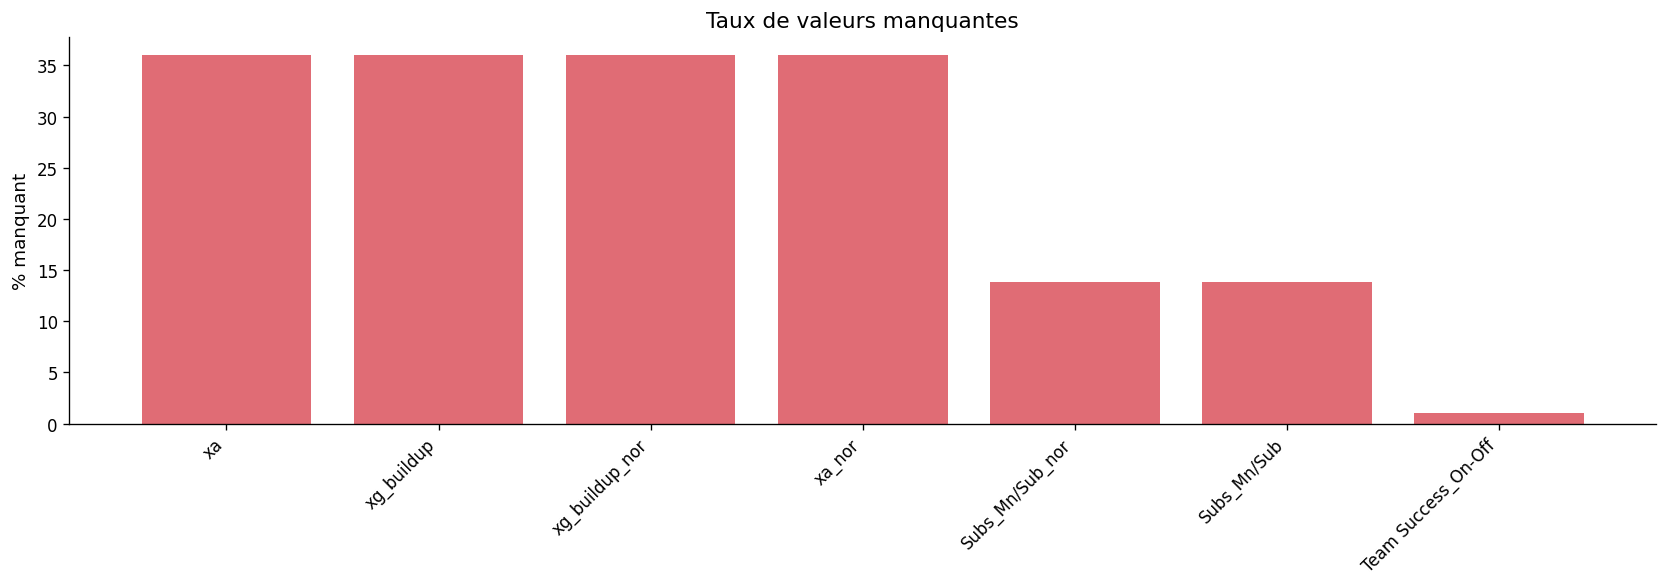

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          1,751
mean      13,261,636
std       18,275,056
min           50,000
25%        2,500,000
50%        6,000,000
75%       18,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.38
Kurtosis : 17.47

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


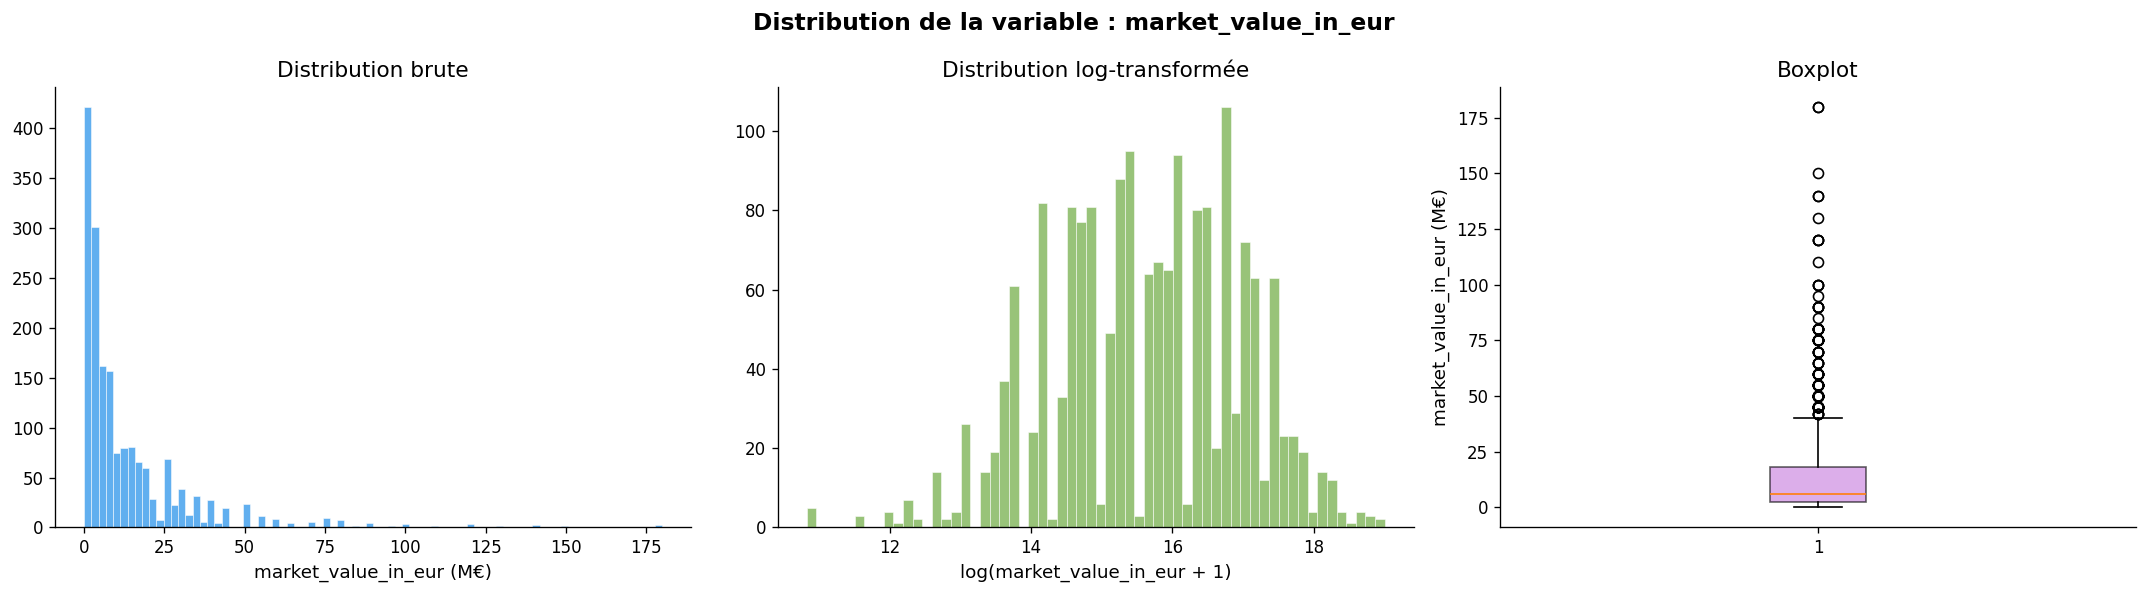

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés



Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


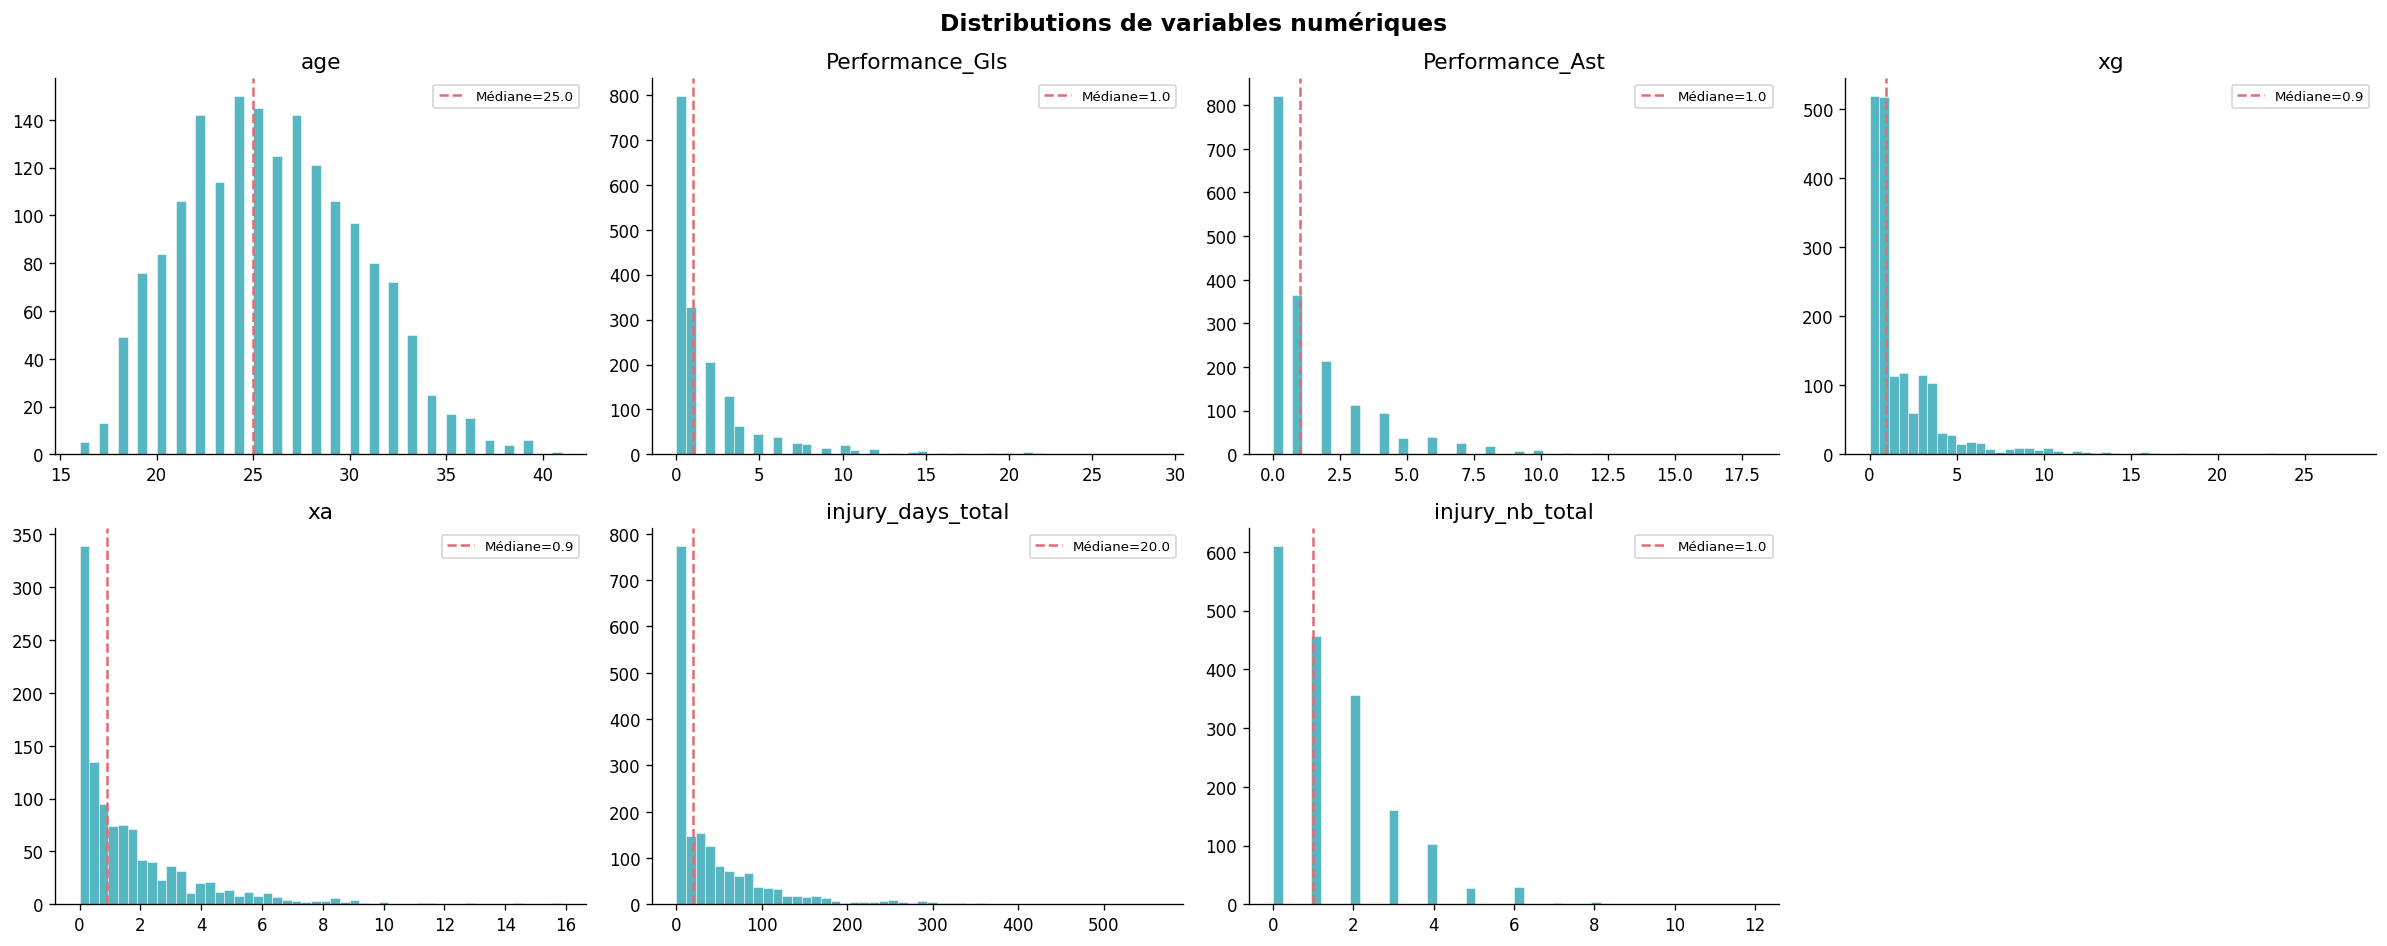

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ENG-Premier League    425
GER-Bundesliga        377
ITA-Serie A           351
FRA-Ligue 1           324
ESP-La Liga           274



players_top_nations.png sauvegardé


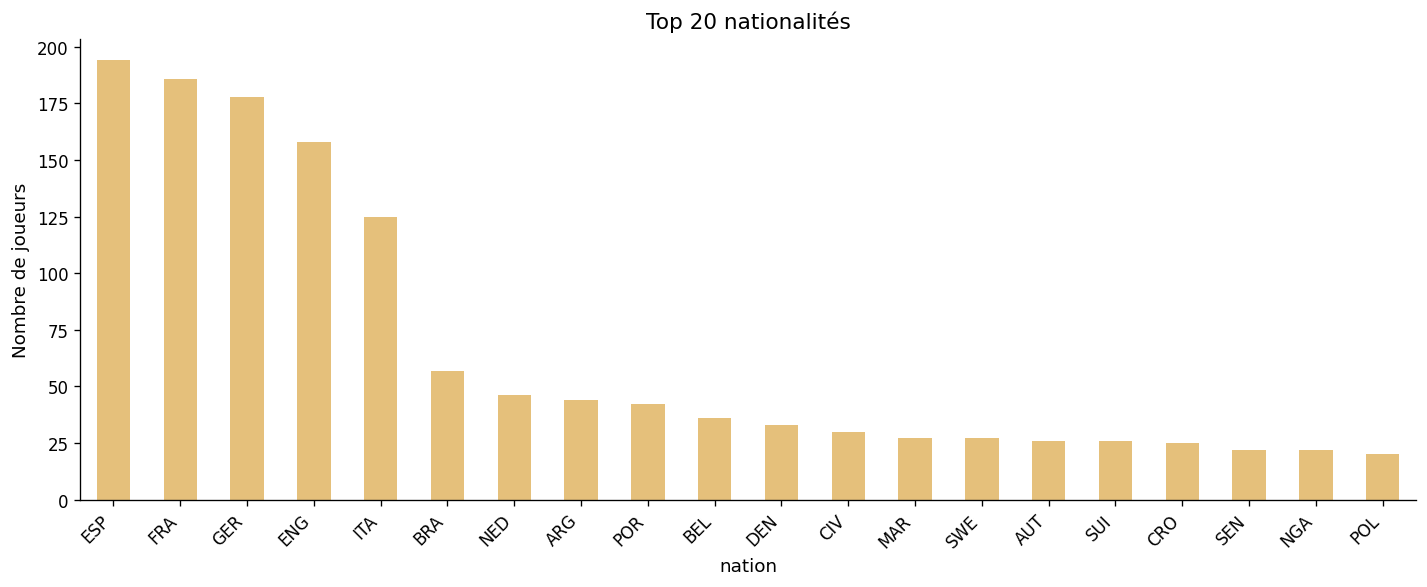

league.png sauvegardé


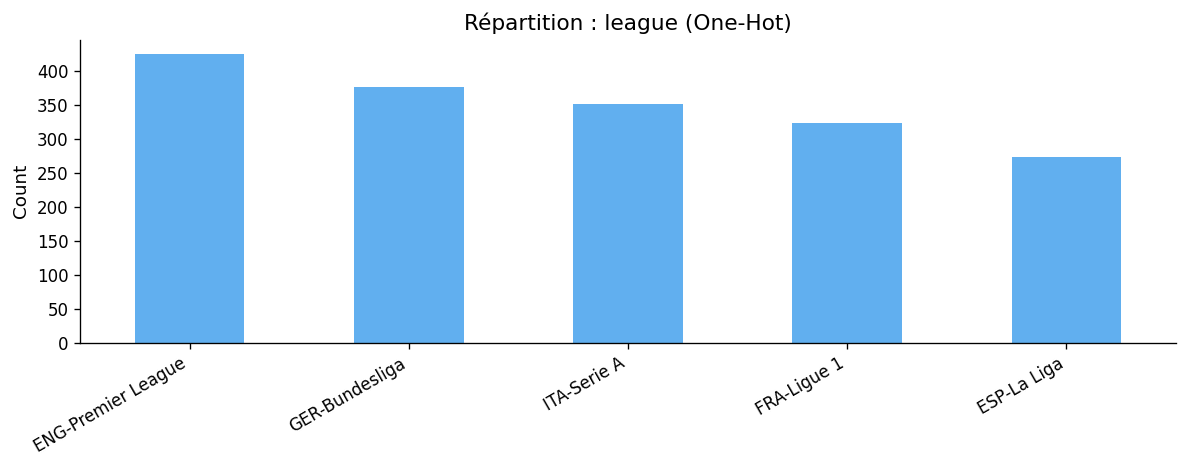

vm_par_league.png sauvegardé


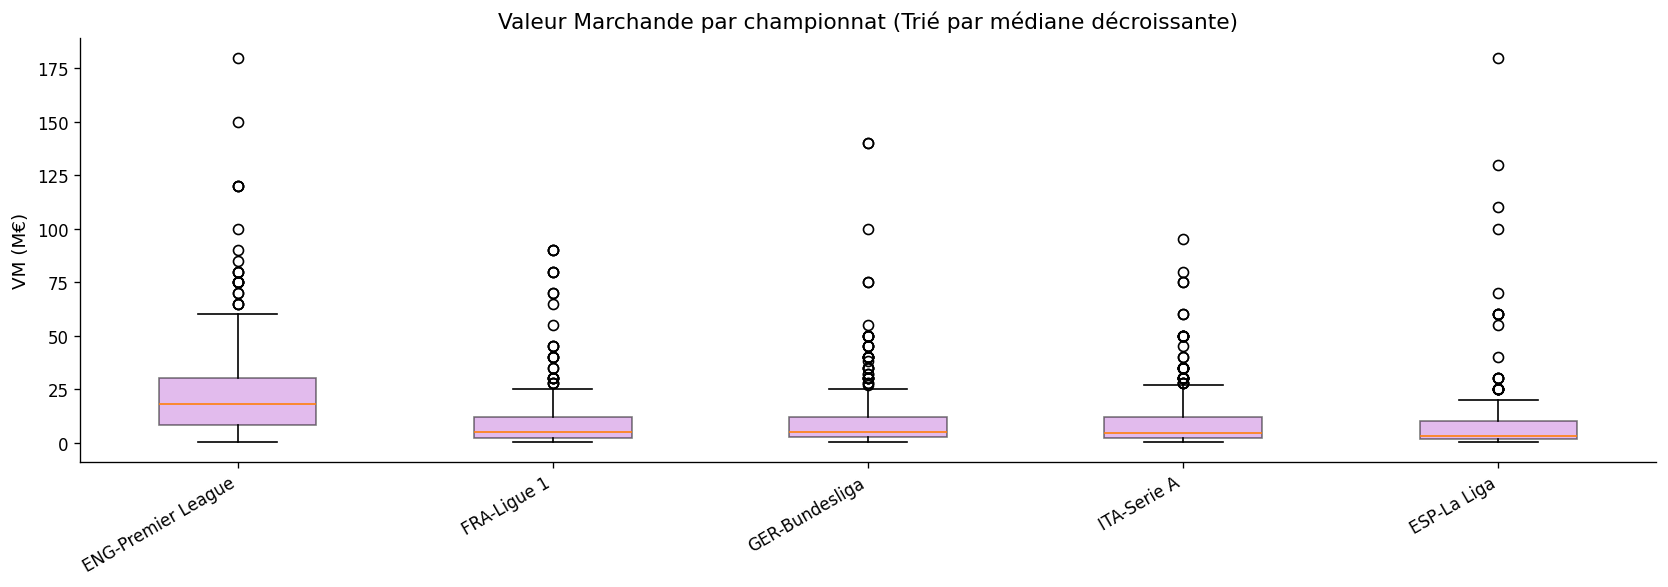

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age             1      0.1                1   1751
  Performance_Gls           183     10.5               38   1751
  Performance_Ast           106      6.1               41   1751
               xg           120      6.9               42   1751
               xa            70      6.2               24   1121
injury_days_total           118      6.7               48   1751
  injury_nb_total            38      2.2               38   1751


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
xa                              0.481644
Performance_Gls                 0.470610
Performance_Ast                 0.463144
xg                              0.380135
injury_nb_total                 0.156757
injury_days_total               0.052398
age                            -0.180768



matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


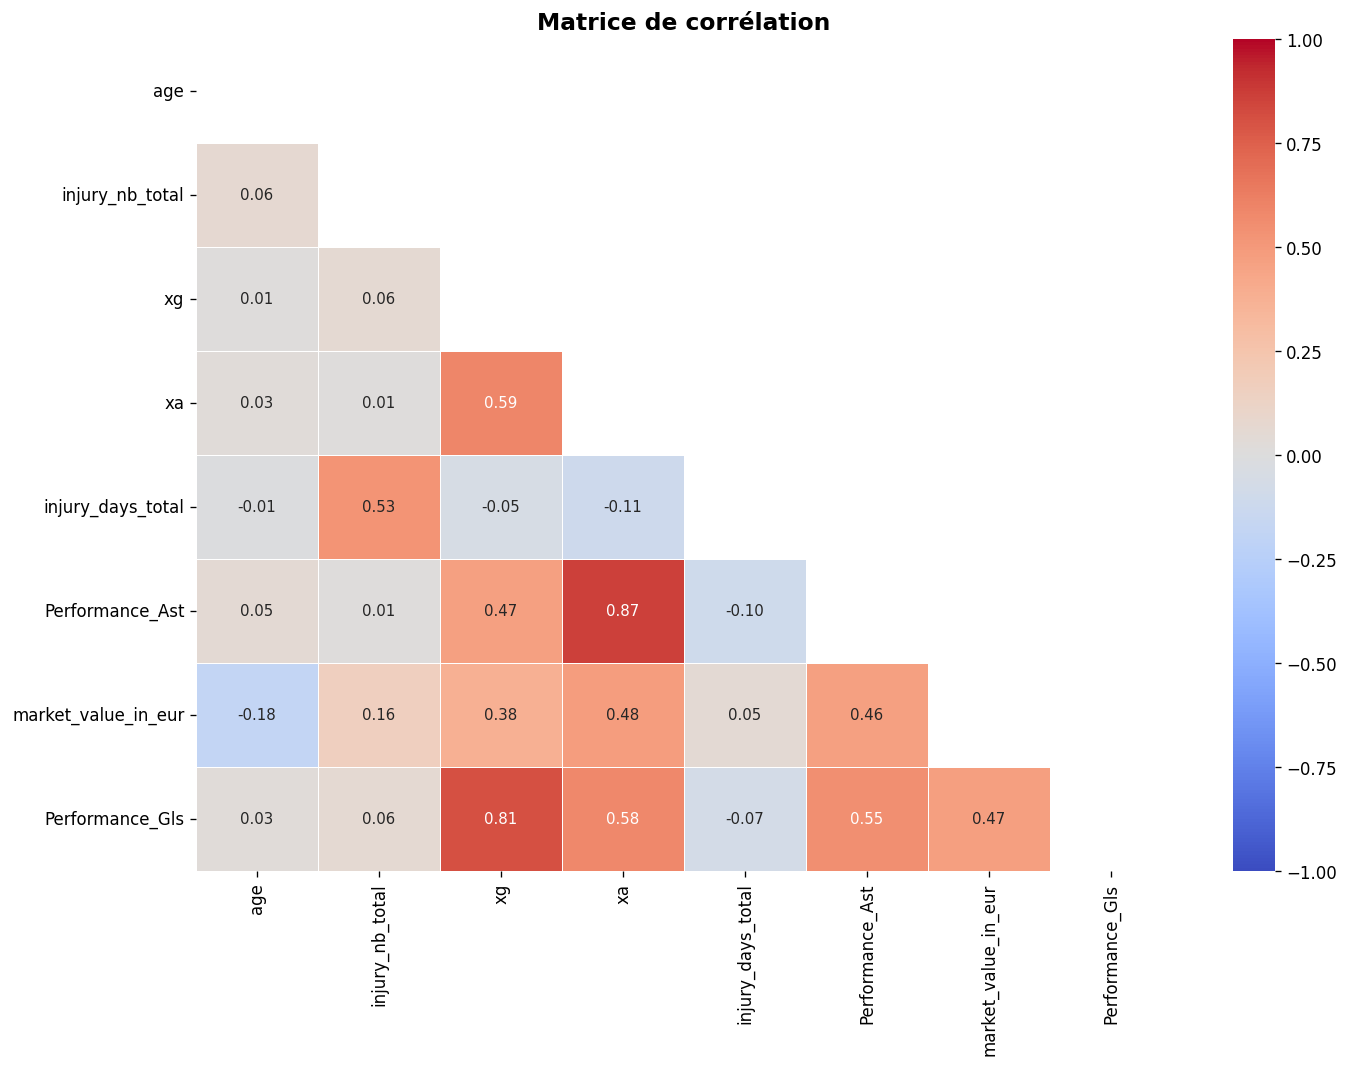


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.555298
Standard_Sh                0.514554
Standard_Sh_nor            0.514554
Standard_SoT_nor           0.510545
Standard_SoT               0.510545
xg_buildup_nor             0.490870
xg_buildup                 0.490870
xa                         0.481644
xa_nor                     0.481644
Performance_G-PK           0.480525
Performance_Gls_nor        0.470610
Performance_Gls            0.470610
Performance_Ast            0.463144
Performance_Ast_nor        0.463144
xg_nor                     0.380135
xg                         0.380135
Playing Time_Starts        0.373600
Playing Time_Starts_nor    0.373600
Playing Time_90s           0.371143


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


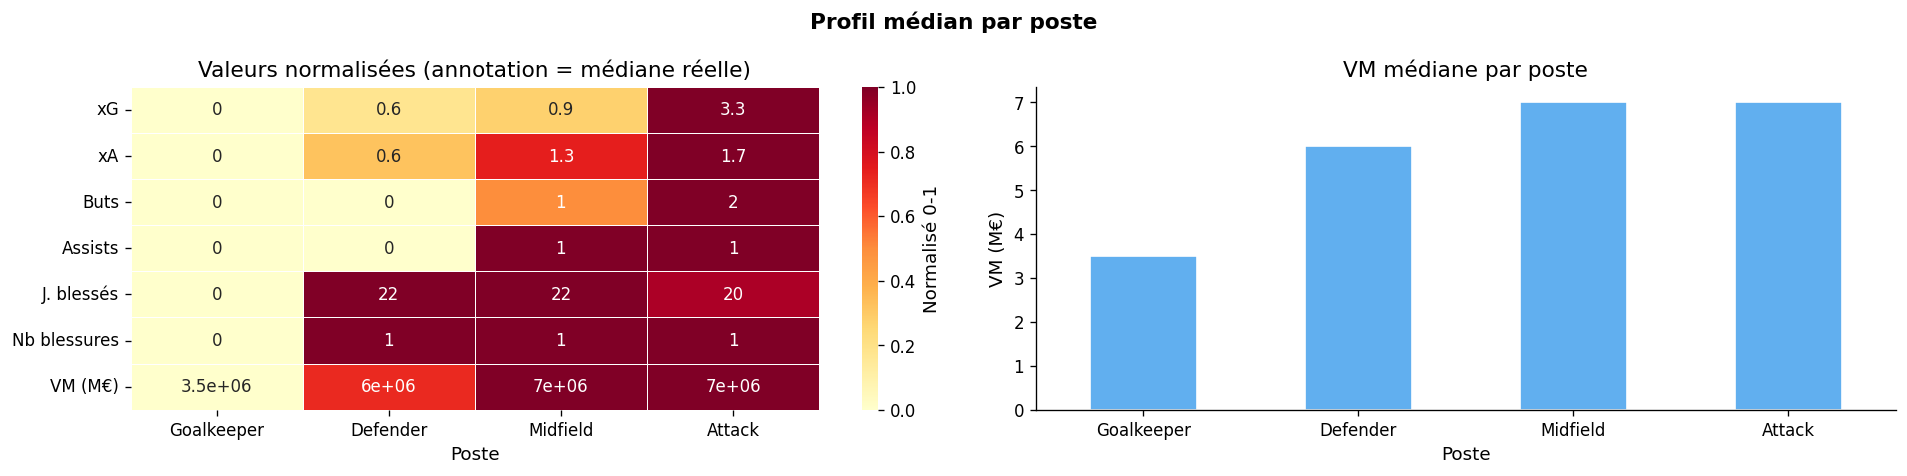

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


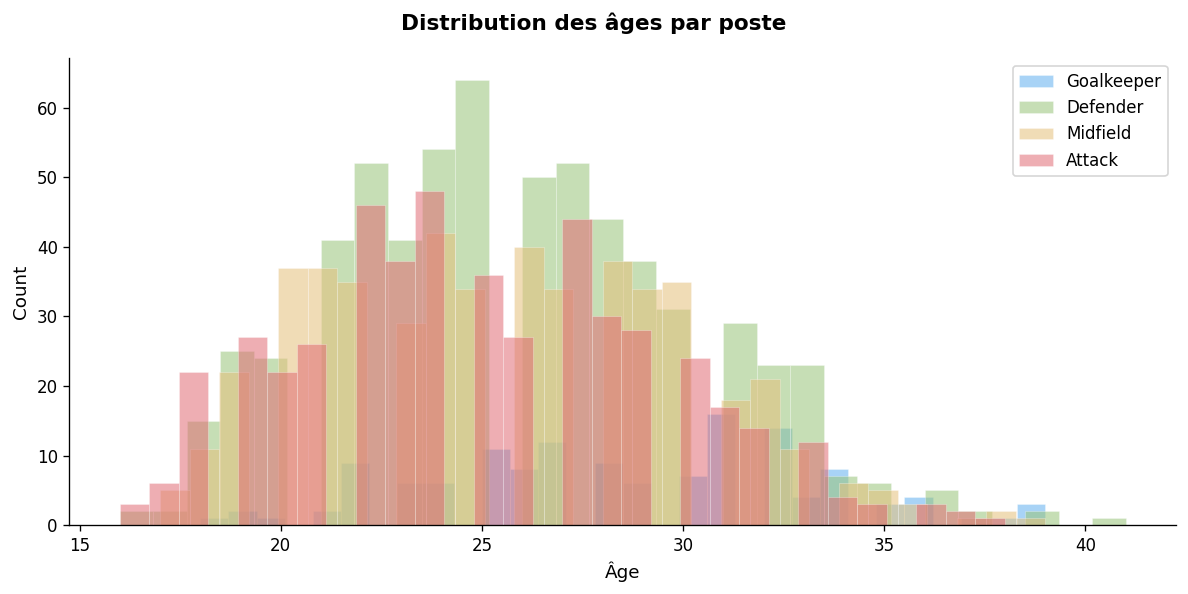


Âge médian par poste
position
Goalkeeper    28.5
Defender      25.0
Midfield      25.0
Attack        25.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste



Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


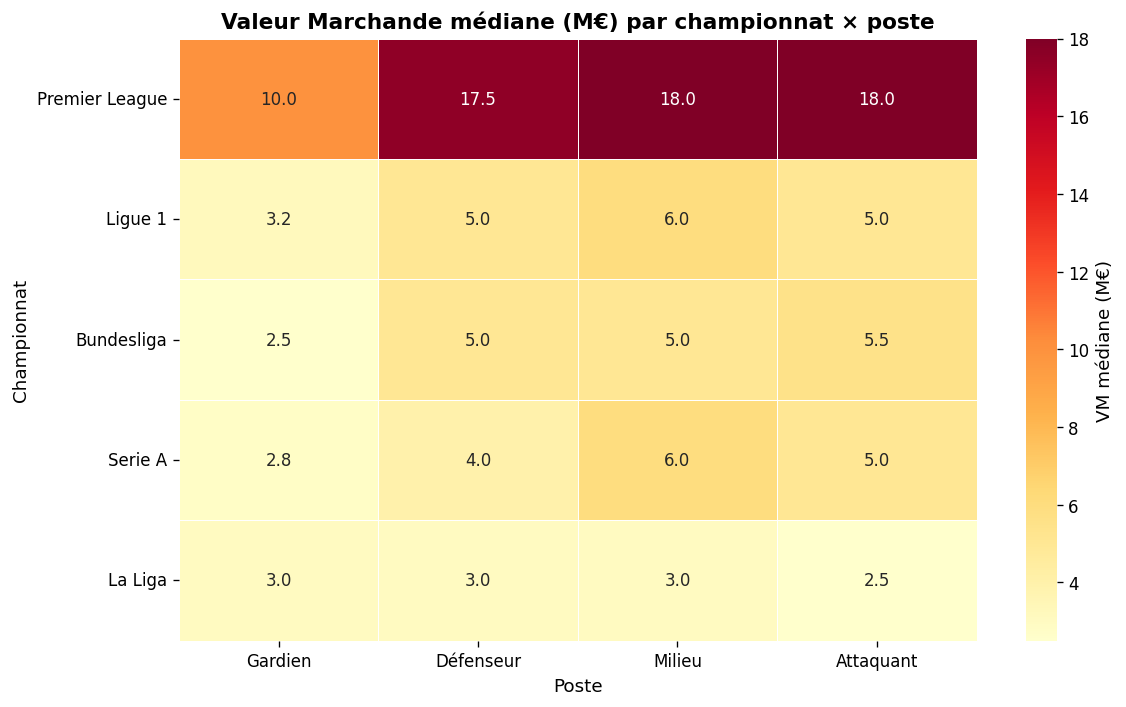

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat



Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


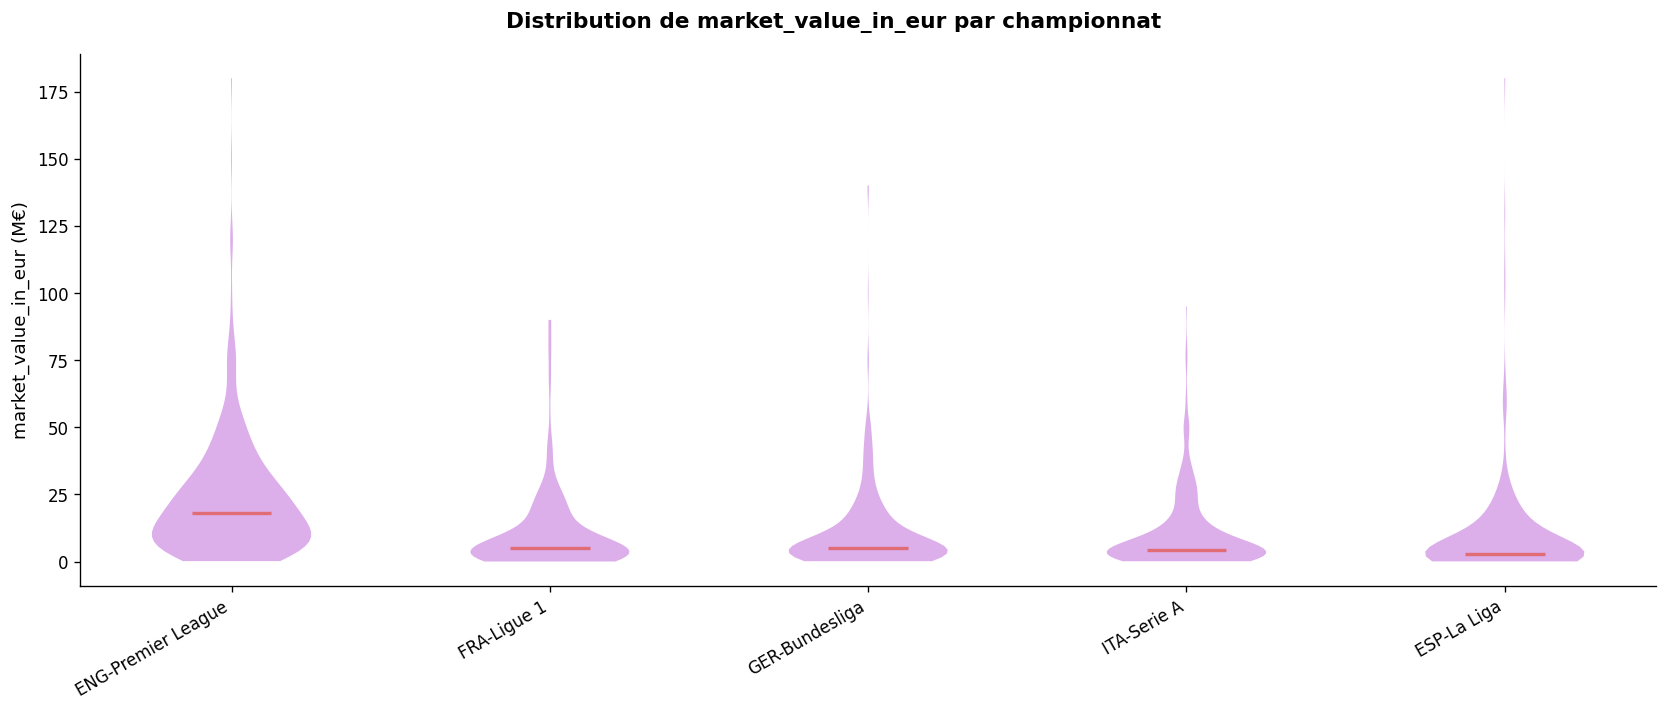

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 13 observations

Top 20 des joueurs les plus chers
             player position  market_value_in_eur  Performance_Gls        xg  Per 90 Minutes_G+A
     Erling Haaland   Attack                180.0               22 23.954593                0.82
    Jude Bellingham Midfield                180.0                9 13.084144                0.62
        Bukayo Saka   Attack                150.0                6  8.943422                0.83
      Florian Wirtz Midfield                140.0               10  0.714602                0.84
      Jamal Musiala Midfield                140.0               12 11.052295                0.70
  Federico Valverde Midfield                130.0                6  2.511641                0.30
        Declan Rice Midfield                120.0                4  3.626993                0.35
        Cole Palmer Midfield                120.0      


Graphique sauvegardé sous : ..\outputs\eda\outliers_top100M_profil.png


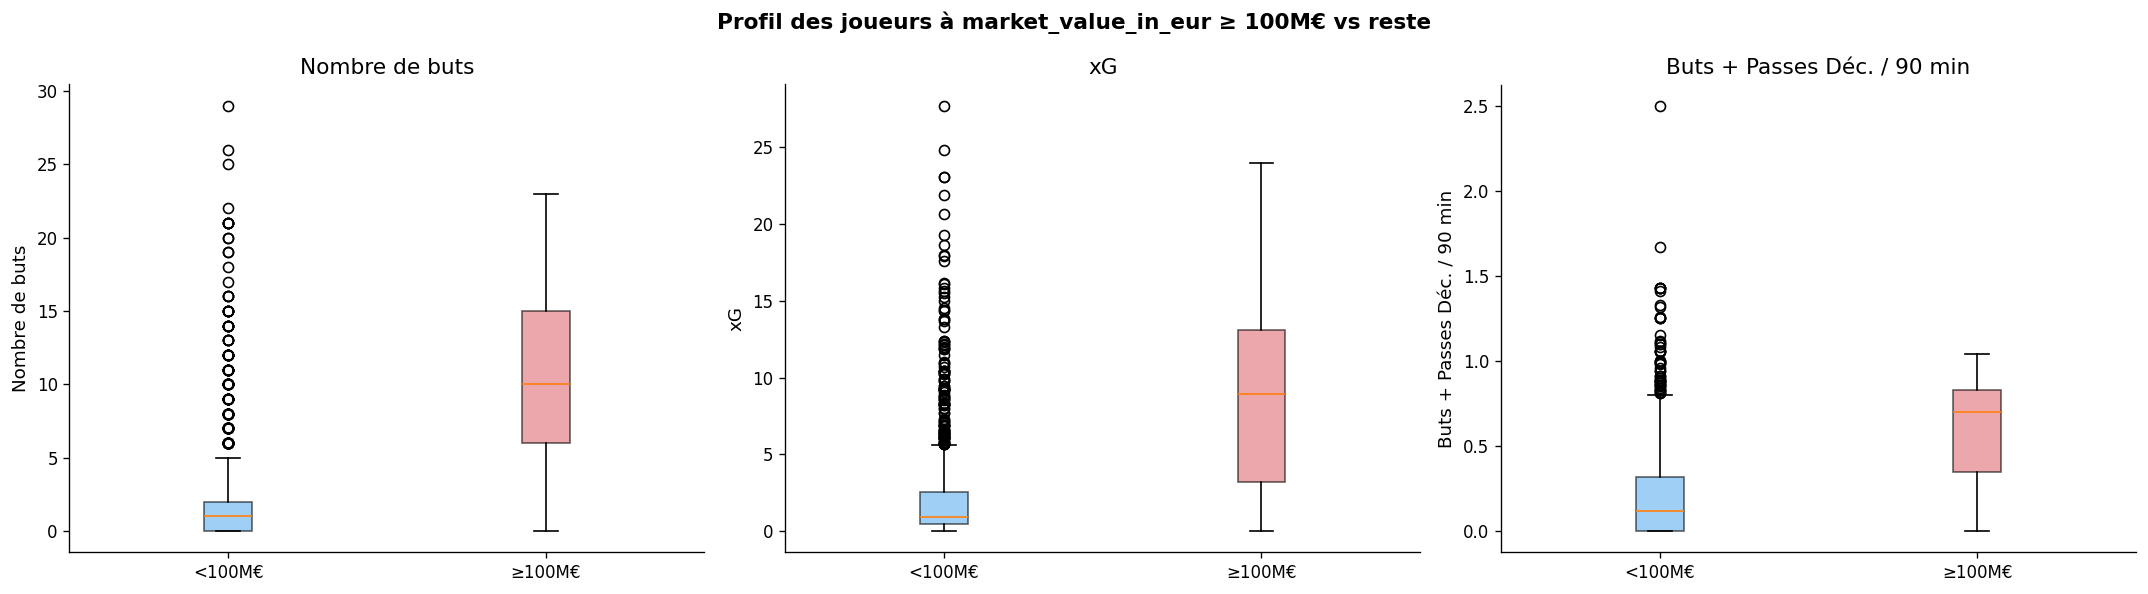

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (1751/1751 lignes analysées) :
  Cohérents (diff = 0)           : 1,648
  Diff ≤ 1 jour                  : 1,648
  Diff > 1 jour (anomalie)       : 103
  Diff max                       : 528 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2024                  6.0     13.261636        1751

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


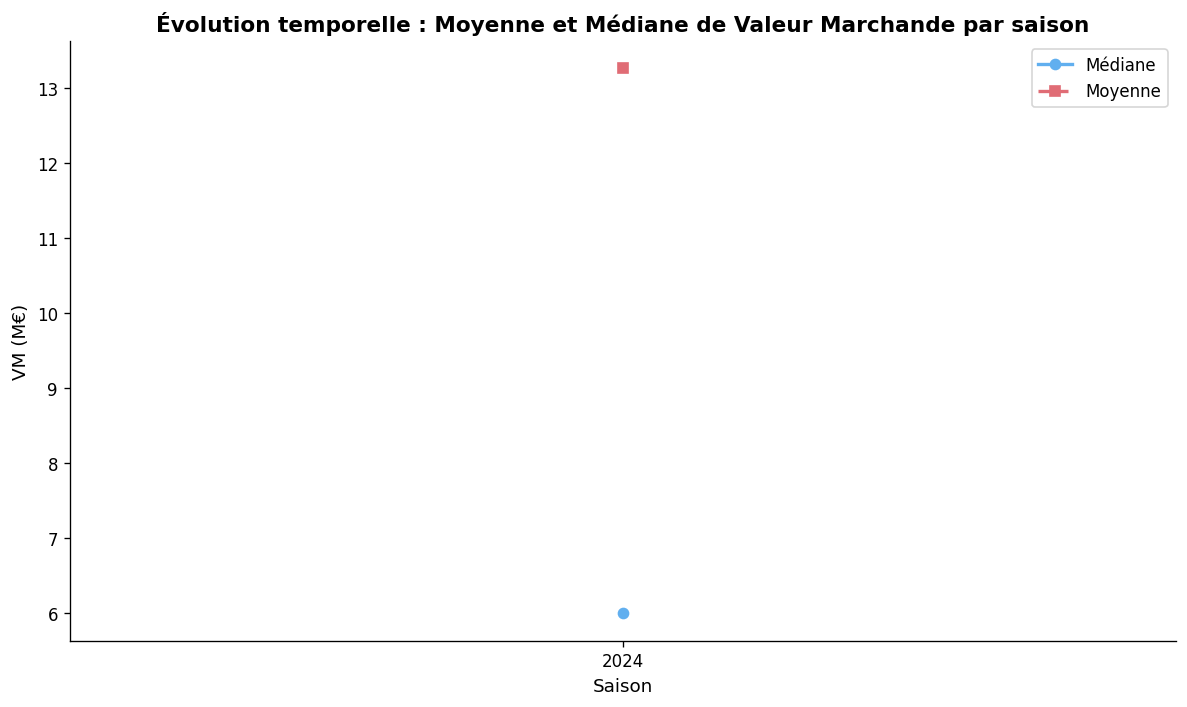

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2024,6.0,13.261636,1751


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
1751 observations valides trouvées pour l'analyse graphique.


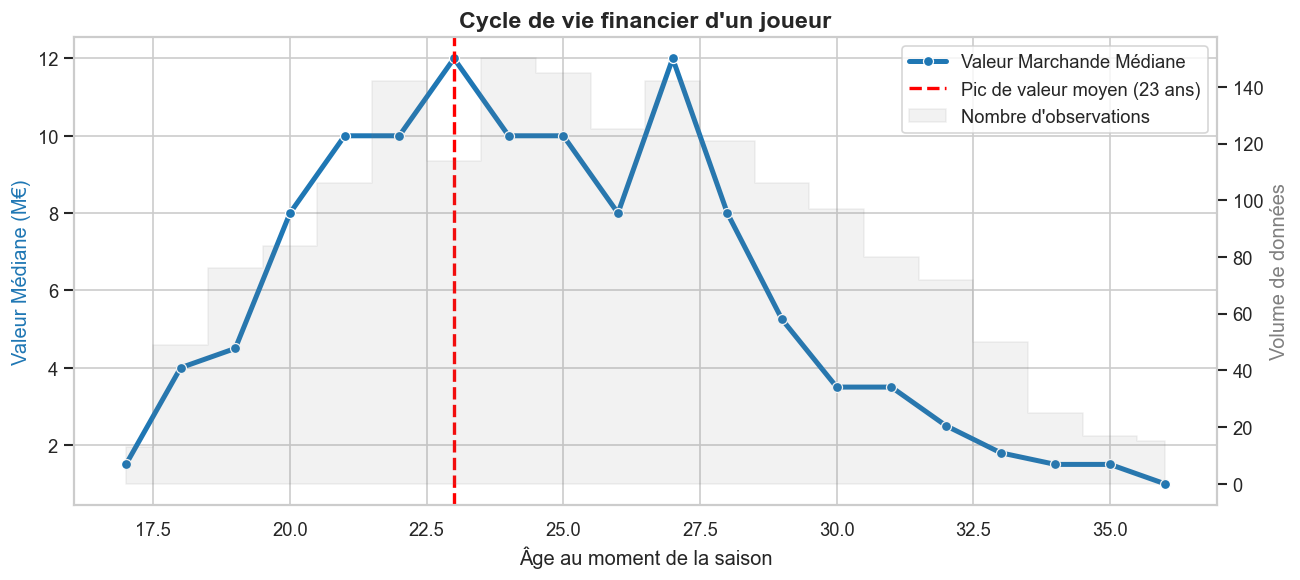


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

In [19]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Cresswell,West Ham United,ENG,35,18,10,9.2,0,0,0,...,0.000,0.025641,0.000000,0.0000,0.00,0.00,0.309565,0.018839,NaN,NaN
1,Aaron Malouda,Lille,FRA,19,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.00,0.000000,0.000000,0.000000,0.000000
2,Aaron Ramsdale,Southampton,ENG,26,30,30,30.0,0,0,0,...,0.100,0.000000,0.000000,0.0000,0.00,0.00,0.064348,0.000000,0.000000,0.096906
3,Aaron Wan-Bissaka,West Ham United,COD,27,36,35,35.0,2,5,2,...,0.000,0.082051,0.054945,0.3125,0.12,0.20,0.203478,0.018839,NaN,NaN
4,Abakar Sylla,Strasbourg,CIV,22,21,10,10.6,1,0,1,...,0.000,0.025641,0.010989,0.2000,0.20,0.50,0.297391,0.019263,0.003555,0.137833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,Ümit Akdag,Toulouse,ROU,21,9,6,5.6,0,0,0,...,0.000,0.010256,0.000000,0.0000,0.00,0.00,0.154783,0.002343,0.003362,0.023779
1747,Đorđe Petrović,Strasbourg,SRB,25,31,31,31.0,0,0,0,...,0.323,0.000000,0.000000,0.0000,0.00,0.00,0.297391,0.000000,NaN,NaN
1748,İlkay Gündoğan,Manchester City,GER,34,33,25,24.7,1,6,1,...,0.000,0.138462,0.076923,0.2593,0.04,0.07,0.337391,0.027984,NaN,NaN
1749,Łukasz Fabiański,West Ham United,POL,39,14,13,12.9,0,0,0,...,0.231,0.000000,0.000000,0.0000,0.00,0.00,0.260870,0.000000,NaN,NaN


Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


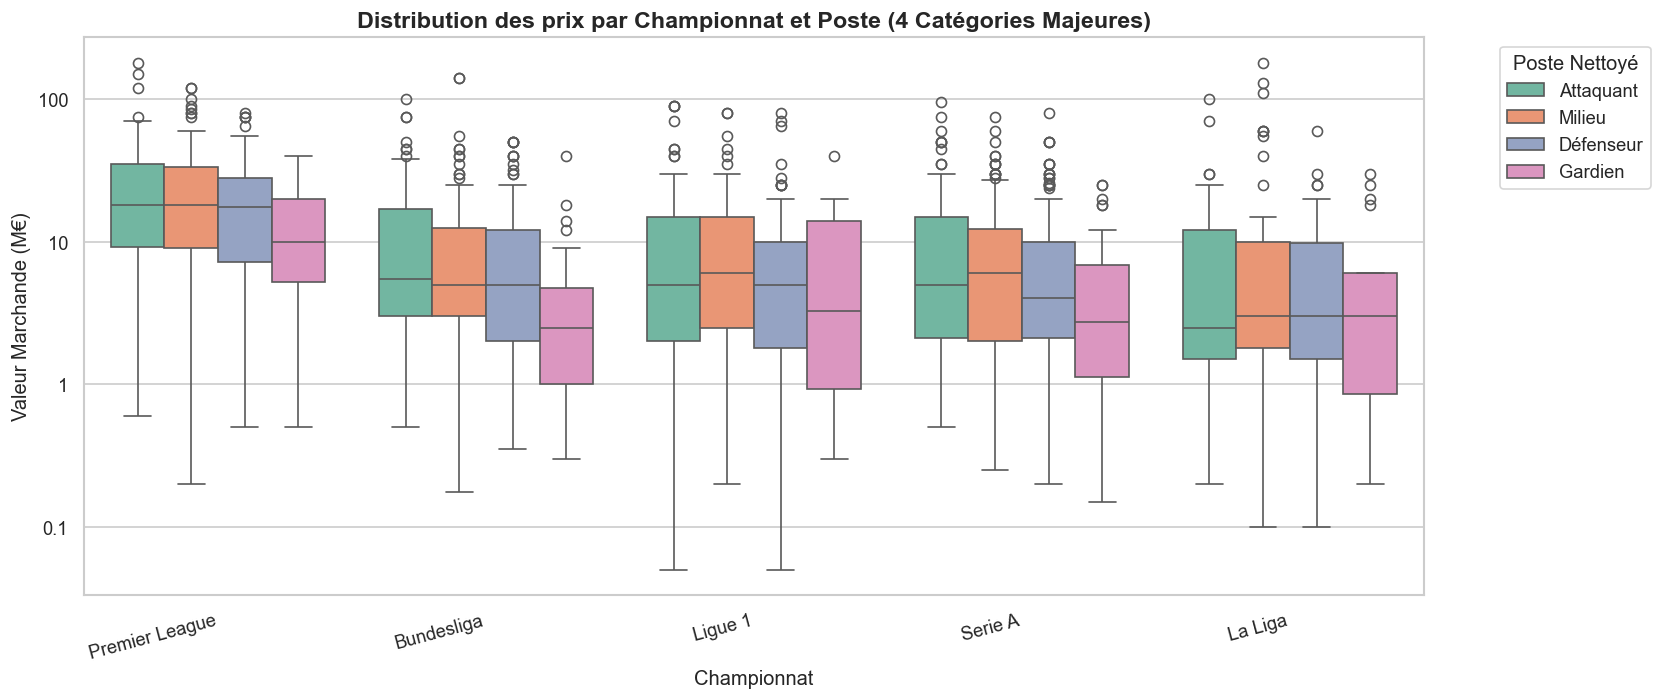


Boxplot généré avec succès.


In [20]:
analyser_distribution_prix_ligue_poste(df_base)

In [21]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,sub_position_Goalkeeper,pos_GK,0.996
1,Playing Time_90s,Playing Time_Starts,0.993
2,pos_GK,Performance_Save%,0.987
3,Performance_G-PK,Performance_Gls,0.983
4,sub_position_Goalkeeper,Performance_Save%,0.983
5,Performance_Saves,Performance_GA,0.970
6,Performance_PKatt,Performance_PK,0.966
7,injury_mollet_tibia_nb_m,injury_mollet_tibia_nb_d,0.964
8,Standard_SoT,Standard_Sh,0.958
9,injury_genou_nb_m,injury_genou_nb_d,0.957


In [22]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Cresswell,West Ham United,ENG,35,18,10,9.2,0,0,0,...,0.000,0.025641,0.000000,0.0000,0.00,0.00,0.309565,0.018839,NaN,NaN
1,Aaron Malouda,Lille,FRA,19,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.00,0.000000,0.000000,0.000000,0.000000
2,Aaron Ramsdale,Southampton,ENG,26,30,30,30.0,0,0,0,...,0.100,0.000000,0.000000,0.0000,0.00,0.00,0.064348,0.000000,0.000000,0.096906
3,Aaron Wan-Bissaka,West Ham United,COD,27,36,35,35.0,2,5,2,...,0.000,0.082051,0.054945,0.3125,0.12,0.20,0.203478,0.018839,NaN,NaN
4,Abakar Sylla,Strasbourg,CIV,22,21,10,10.6,1,0,1,...,0.000,0.025641,0.010989,0.2000,0.20,0.50,0.297391,0.019263,0.003555,0.137833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,Ümit Akdag,Toulouse,ROU,21,9,6,5.6,0,0,0,...,0.000,0.010256,0.000000,0.0000,0.00,0.00,0.154783,0.002343,0.003362,0.023779
1747,Đorđe Petrović,Strasbourg,SRB,25,31,31,31.0,0,0,0,...,0.323,0.000000,0.000000,0.0000,0.00,0.00,0.297391,0.000000,NaN,NaN
1748,İlkay Gündoğan,Manchester City,GER,34,33,25,24.7,1,6,1,...,0.000,0.138462,0.076923,0.2593,0.04,0.07,0.337391,0.027984,NaN,NaN
1749,Łukasz Fabiański,West Ham United,POL,39,14,13,12.9,0,0,0,...,0.231,0.000000,0.000000,0.0000,0.00,0.00,0.260870,0.000000,NaN,NaN


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


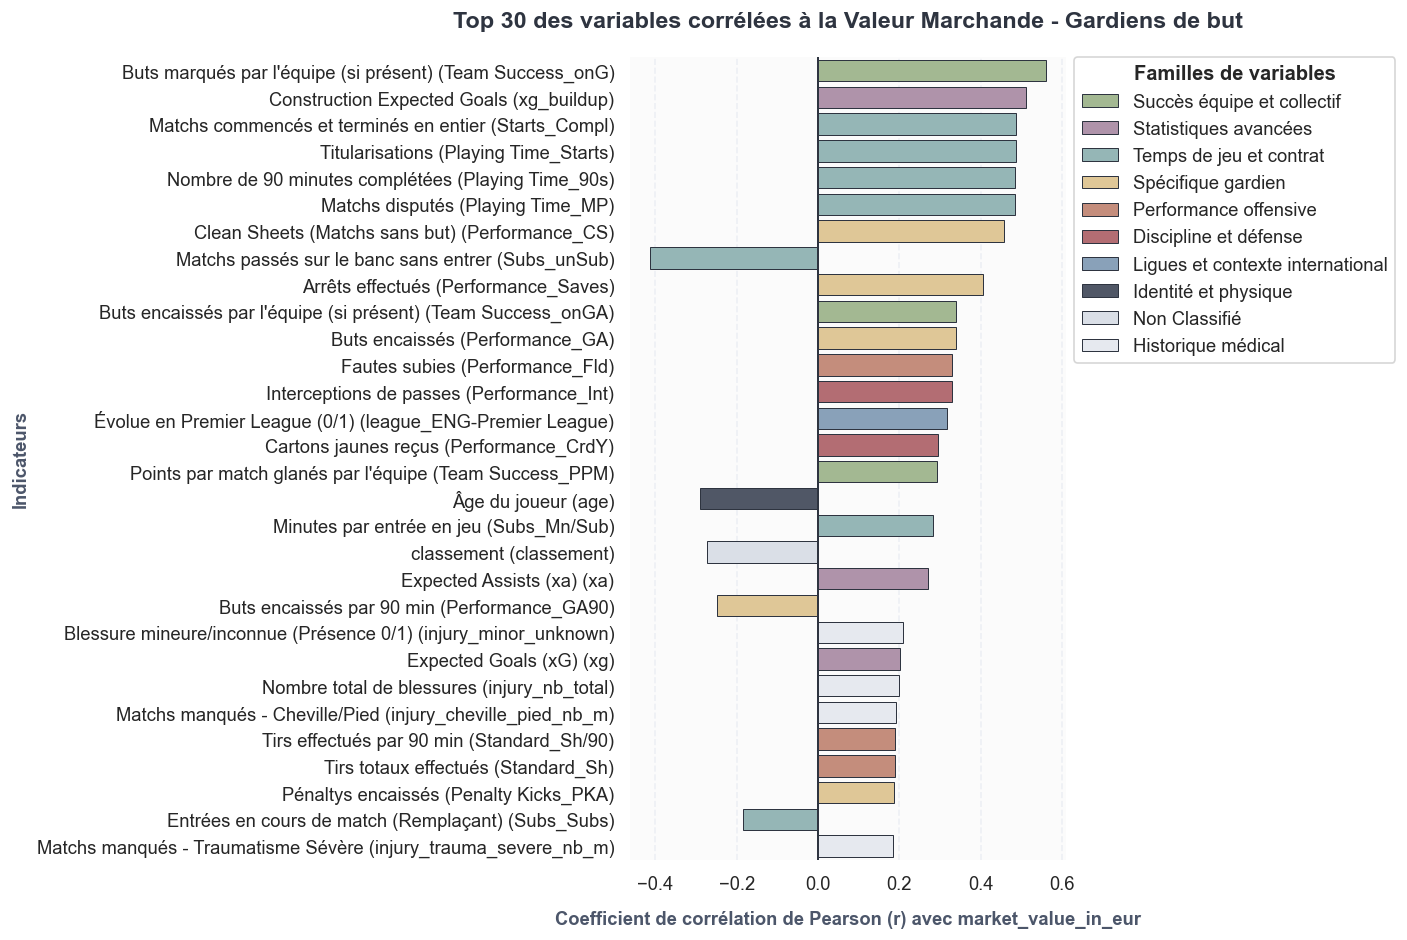

,Variable,Description,Famille,Corr_Cible_Brute
0,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.560
1,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.512
2,Starts_Compl,Matchs commencés et terminés en entier (Starts...,Temps de jeu et contrat,0.486
3,Playing Time_Starts,Titularisations (Playing Time_Starts),Temps de jeu et contrat,0.486
4,Playing Time_90s,Nombre de 90 minutes complétées (Playing Time_...,Temps de jeu et contrat,0.485
5,Playing Time_MP,Matchs disputés (Playing Time_MP),Temps de jeu et contrat,0.485
6,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.458
7,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.413
8,Performance_Saves,Arrêts effectués (Performance_Saves),Spécifique gardien,0.405
9,Team Success_onGA,Buts encaissés par l'équipe (si présent) (Team...,Succès équipe et collectif,0.338


In [23]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [24]:
# Filtrez sur les gardiens uniquement avant de calculer la corrélation
df_gardiens = df_base[df_base["pos_GK"] == 1]

# Calculez la corrélation pearson
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.338138
market_value_in_eur        0.338138             1.000000


In [25]:
# Corrélation brute
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

# Corrélation entre les buts encaissés et la VM, mais à temps de jeu strictement égal
p_corr = pg.partial_corr(
    data=df_gardiens,
    x="Performance_GA",
    y="market_value_in_eur",
    covar="Playing Time_90s",
)

print(p_corr)

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.338138
market_value_in_eur        0.338138             1.000000
           n         r            CI95     p_val
pearson  133 -0.256118  [-0.41, -0.09]  0.003035


La corrélation à temps de jeu égal est bien négative : $-0.479881$, une valeur plus élevée que la corrélation de la colonne Performance_GA90 ($-0,20$). 

C'est parce que la variable Performance_GA90 (buts/90min) souffre d'un autre biais : le biais des petits échantillons.
Exemple : Un gardien remplaçant très faible entre en jeu, joue 10 minutes et prend 2 buts. Son ratio par 90 minutes explose (il monte à $18,0$ buts par match !). 

Ce genre de valeur extrême (outlier) vient "bruiter" et affaiblir votre corrélation Pearson classique sur la colonne des ratios.
La corrélation partielle, elle, étudie les volumes bruts sous contrôle mathématique. Elle contourne ce bruit des ratios extrêmes sur des petits temps de jeu, ce qui donne la vraie mesure de l'impact négatif des buts encaissés sur la valeur marchande d'un gardien.